# Heart Disease Detection
Raphaël TRINQUANT
October, 2025

**Abstract**
This project focuses on building a predictive model for the detection of heart disease using machine learning techniques. Based on the Cleveland Heart Disease dataset from the UCI repository, which includes 14 medical attributes, our analysis begins with a comprehensive data exploration (EDA). We then implement and comparatively evaluate several classification algorithms—notably Logistic Regression, Decision Trees, and Random Forest—to identify the most effective model for this diagnostic task. 

Source : https://archive.ics.uci.edu/dataset/45/heart+disease + https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland

# I. Exploratory data analysis

## 1. Load the dataset

In [2]:
# import necessary libraries
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, roc_curve



# Load the dataset
df = pd.read_csv('heart_disease.csv', sep=';')
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Class
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  Class     303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Columns presentation (from Kaggle)


- **Age**: Patients Age in years (Numeric)
- **Sex**: Gender (Male : 1; Female : 0) (Nominal)
- **cp**: Type of chest pain experienced by patient. This term categorized into 4 category. 0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
- **trestbps**: patient's level of blood pressure at resting mode in mm/HG (Numerical)
- **chol**: Serum cholesterol in mg/dl (Numeric)
- **fbs**: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)
- **restecg**: Result of electrocardiogram while at rest are represented in 3 distinct values 0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) 2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
- **thalach**: Maximum heart rate achieved (Numeric)
- **exang**: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
- **oldpeak**: Exercise induced ST-depression in relative with the state of rest (Numeric)
- **slope**: ST segment measured in terms of slope during peak exercise 0: up sloping; 1: flat; 2: down sloping(Nominal)
- **ca**: The number of major vessels (0–3)(nominal) 
- **thal**: A blood disorder called thalassemia 3: NULL 1: normal blood flow 6: fixed defect (no blood flow in some part of the heart) 7: reversible defect (a blood flow is observed but it is not normal(nominal)
- **Class**: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.


## 2. Traitment of missing values

In [4]:
# number of missing values per column
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# suppress rows with missing values
df_cleaned = df.dropna()

ca      4
thal    2
dtype: int64

With almost no missing values, we decide to remove these records. The loss of information is insignificant.

However, it's worth noting that Decision Tree and Random Forest models can directly handle these missing data points through surrogate splits. We are not employing this technique at the moment, but we can consider it as it also plays a role in determining feature importance, an interesting dimension when focusing on model explainability.

## 3. Traitment of outliers

In [5]:
# Extraction of categorical columns
nominal_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'Class']
df_binary = df_cleaned[nominal_columns]  

# Extraction of numerical columns
numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_numerical = df_cleaned[numerical_columns]



display(df_binary.head())
display(df_numerical.head())


,sex,cp,fbs,restecg,exang,slope,ca,thal,Class
0,1,1,1,2,0,3,0.0,6.0,0
1,1,4,0,2,1,2,3.0,3.0,1
2,1,4,0,2,1,2,2.0,7.0,1
3,1,3,0,0,0,3,0.0,3.0,0
4,0,2,0,2,0,1,0.0,3.0,0


,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.3
1,67,160,286,108,1.5
2,67,120,229,129,2.6
3,37,130,250,187,3.5
4,41,130,204,172,1.4


In [6]:
# Outliers detection and treatment
for col in df_numerical.columns:
    Q1 = df_numerical[col].quantile(0.25)
    Q3 = df_numerical[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_numerical[(df_numerical[col] < lower_bound) | (df_numerical[col] > upper_bound)]
    print(f'Number of outliers in {col}: {outliers.shape[0]}')

#    df_numerical = df_numerical[(df_numerical[col] >= lower_bound) & (df_numerical[col] <= upper_bound)]

Number of outliers in age: 0
Number of outliers in trestbps: 9
Number of outliers in chol: 5
Number of outliers in thalach: 1
Number of outliers in oldpeak: 5


Almost no atypical values. We choosed to keep all to because in order to preserve the maximum of information.

## 4. Boxplots and distributions

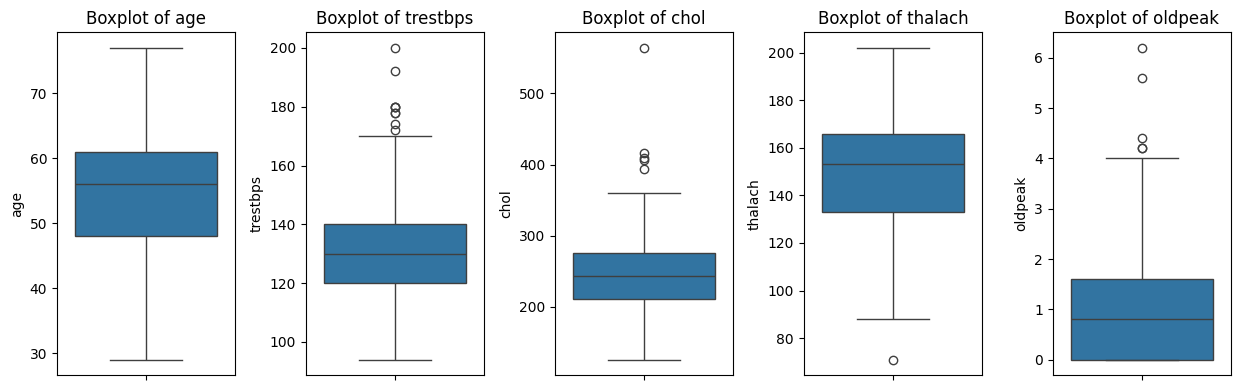

In [7]:
# boxplots
n_cols  = len(df_numerical.columns)

if n_cols > 0:
    
    plots_per_row = 6
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(df_numerical.columns):
        ax = axes[i] 
        sns.boxplot(data=df_numerical, y=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')
        ax.set_ylabel(col)
        ax.set_xlabel('') 

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")

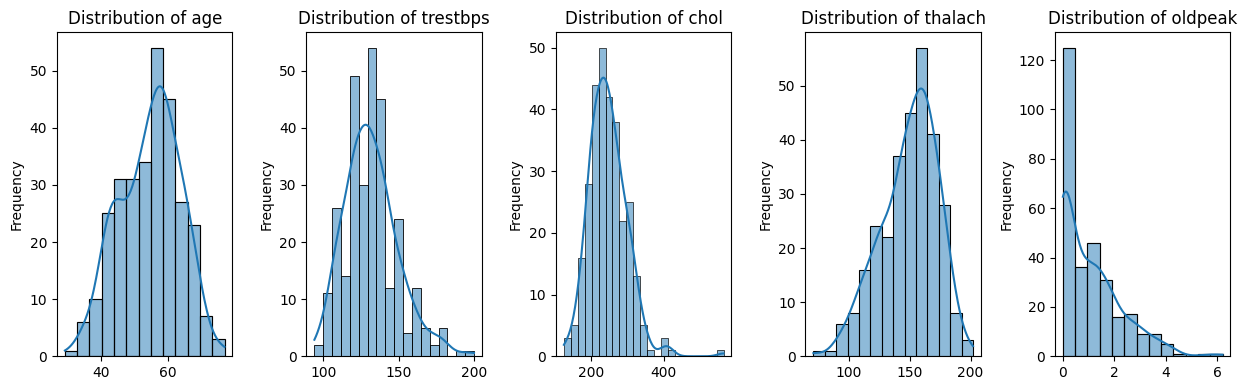

In [8]:
n_cols  = len(df_numerical.columns)
if n_cols > 0:
    
    plots_per_row = 6
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    
    axes = axes.flatten()
    for i, col in enumerate(df_numerical.columns):
        ax = axes[i]  
        sns.histplot(data=df_numerical, x=col, kde=True, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('') 
        ax.set_ylabel('Frequency')

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")


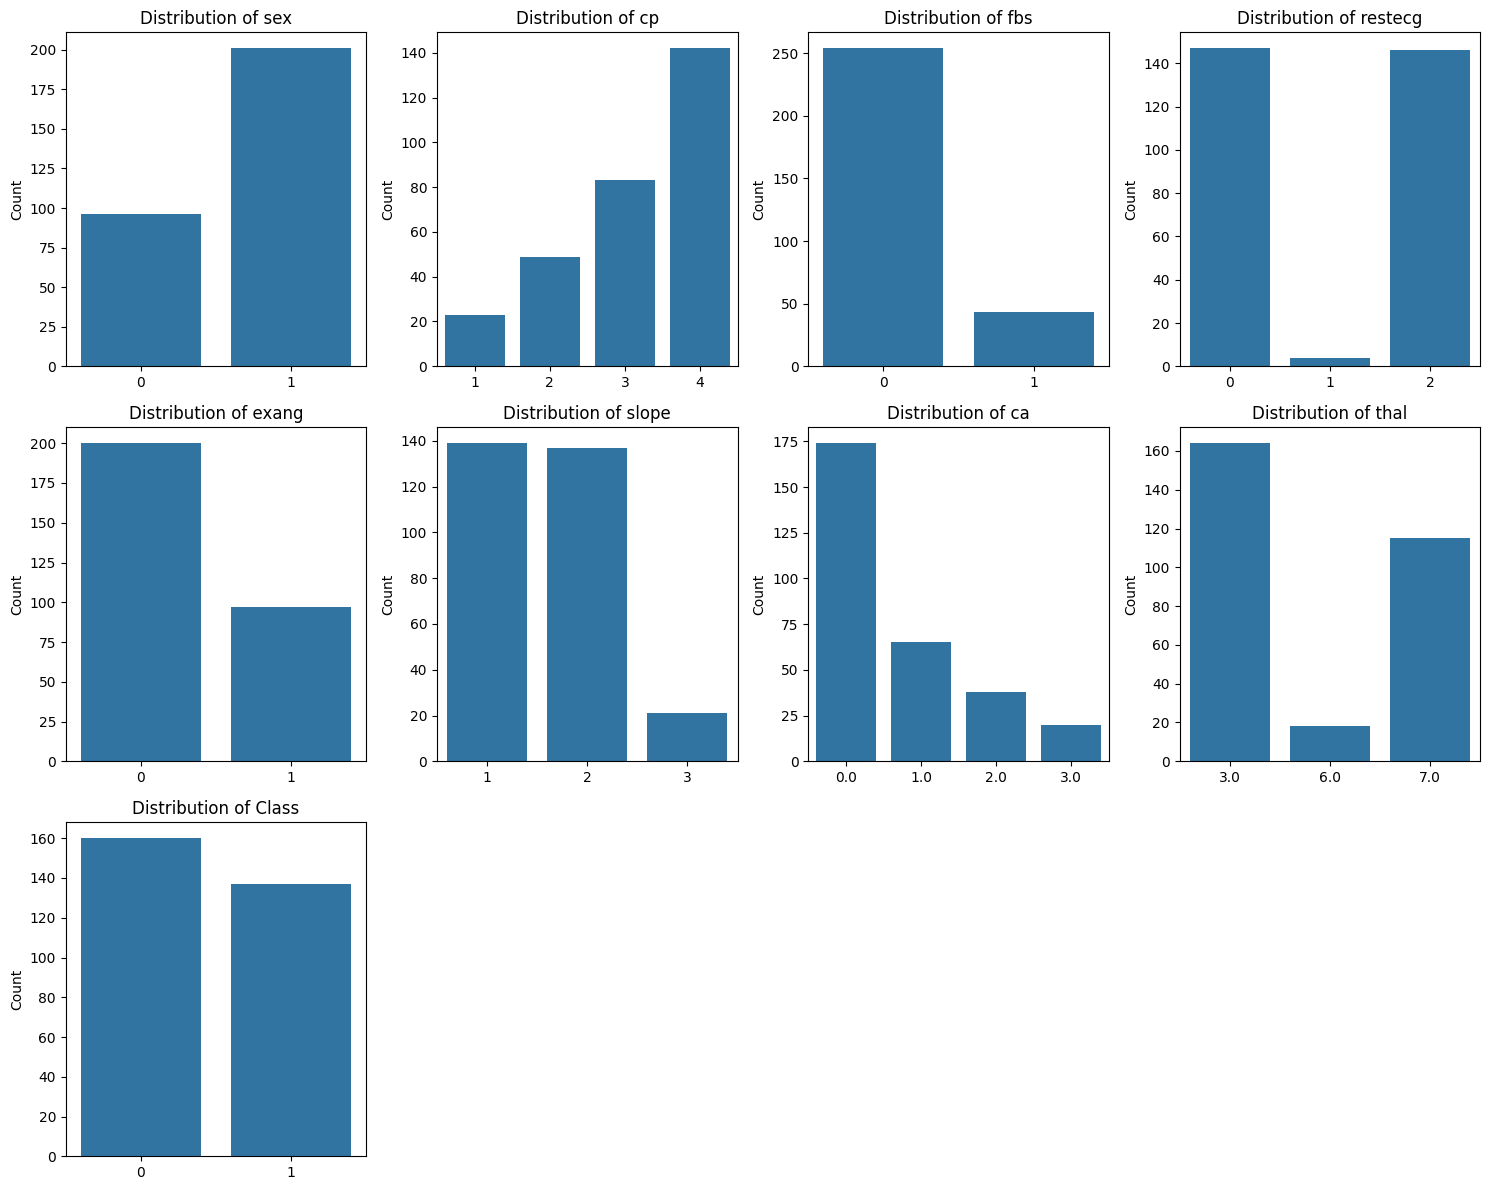

In [9]:
# Display distribution of binary variables
n_cols  = len(df_binary.columns)
if n_cols > 0:
    
    plots_per_row = 4
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    
    axes = axes.flatten()
    for i, col in enumerate(df_binary.columns):
        ax = axes[i]  
        sns.countplot(data=df_binary, x=col, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('') 
        ax.set_ylabel('Count')

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

Box plots and distribution graphs allow us to verify the quality of the data. We observe that the target variable, "Class," is reasonably well balanced. The opposite case could have caused problems in the application of certain models, particularly when trying to detect members of the minority class (e.g., diseased patients/cases).

## 5. Matrix of correlation

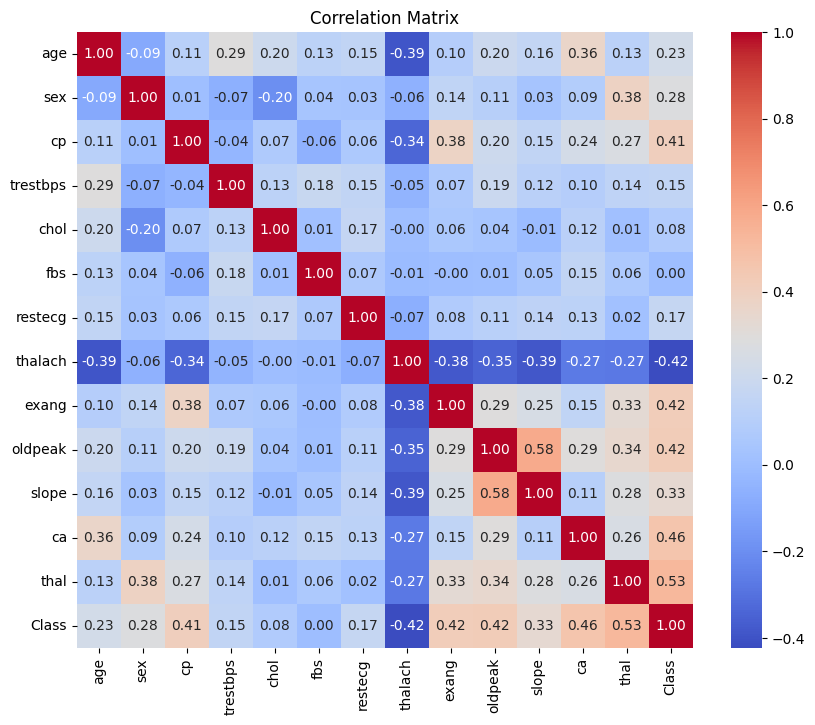

In [10]:
# matrix correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

We do not observe strong collinearity (maximum 0.58). Therefore, we decide to keep all the columns. For the sake of interpretability, we will also not perform Principal Component Analysis (PCA)

# II. Logistic Regression

In [11]:
# Data preparation
X = df_cleaned.iloc[:, :-1]
y = df_cleaned.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Cross-Validation

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
# Make a prediction on the test data
y_pred_lr = model_lr.predict(X_test)

,Logistic Regression
Accuracy,0.8833
Precision,0.8400
Sensitivity,0.8750
Specificity,0.8889
F1-score,0.8571
AUC (ROC),0.9468


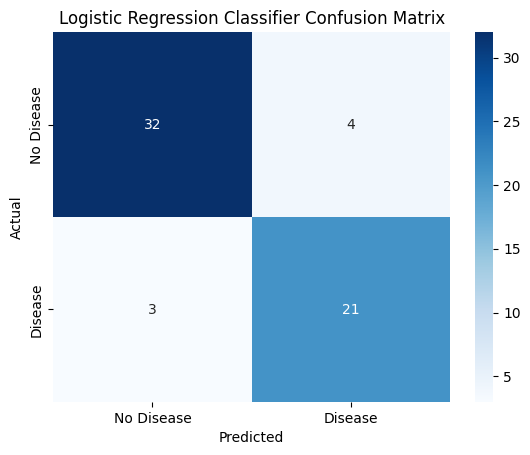

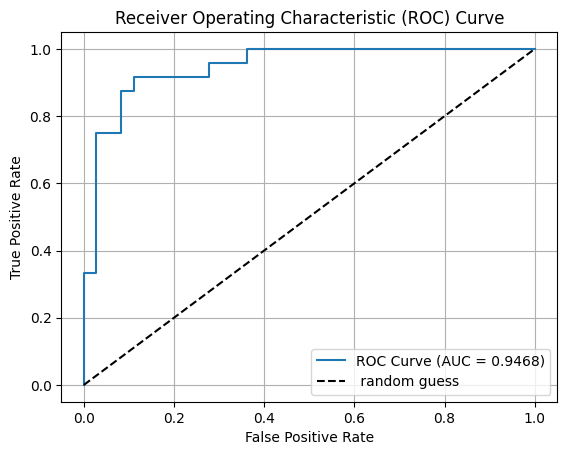

In [13]:
# Evaluation
# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
sensitivity_lr = recall_score(y_test, y_pred_lr)  # sensitivity
cm_lr = confusion_matrix(y_test, y_pred_lr)
specificity_lr = cm_lr[0,0] / (cm_lr[0,0] + cm_lr[0,1]) if (cm_lr[0,0] + cm_lr[0,1]) > 0 else np.nan
f1_lr = f1_score(y_test, y_pred_lr)
auc_score_lr = roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_index = [
     'Accuracy',
     'Precision', 
     'Sensitivity',
     'Specificity',
     'F1-score',
     'AUC (ROC)'
]
metrics_lr = {
     'Logistic Regression': [
          accuracy_lr,
          precision_lr,
          sensitivity_lr,
          specificity_lr,
          f1_lr, 
          auc_score_lr
     ]
}

metrics_lr_df = pd.DataFrame(metrics_lr, index=metrics_index)
display(metrics_lr_df.round(4))

# plot confusion matrix
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresholds = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'ROC Curve (AUC = {auc_score_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

# III. Decision Tree Method

In [14]:
# Choice of the best hyperparamaters (tuning)
model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [None, 2, 3, 5],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [2, 3, 4, 5],
    'ccp_alpha' : [0.03, 0.01, 0]
}

grid_search = GridSearchCV(estimator=model_dt, param_grid=param_grid, cv=5, scoring = 'accuracy')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)

# Train the tree with best hyperparameters
model_dt = best_estimator
model_dt.fit(X_train, y_train)

Best Hyperparameters: {'ccp_alpha': 0.01, 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Estimator: DecisionTreeClassifier(ccp_alpha=0.01, min_samples_leaf=5, random_state=42)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


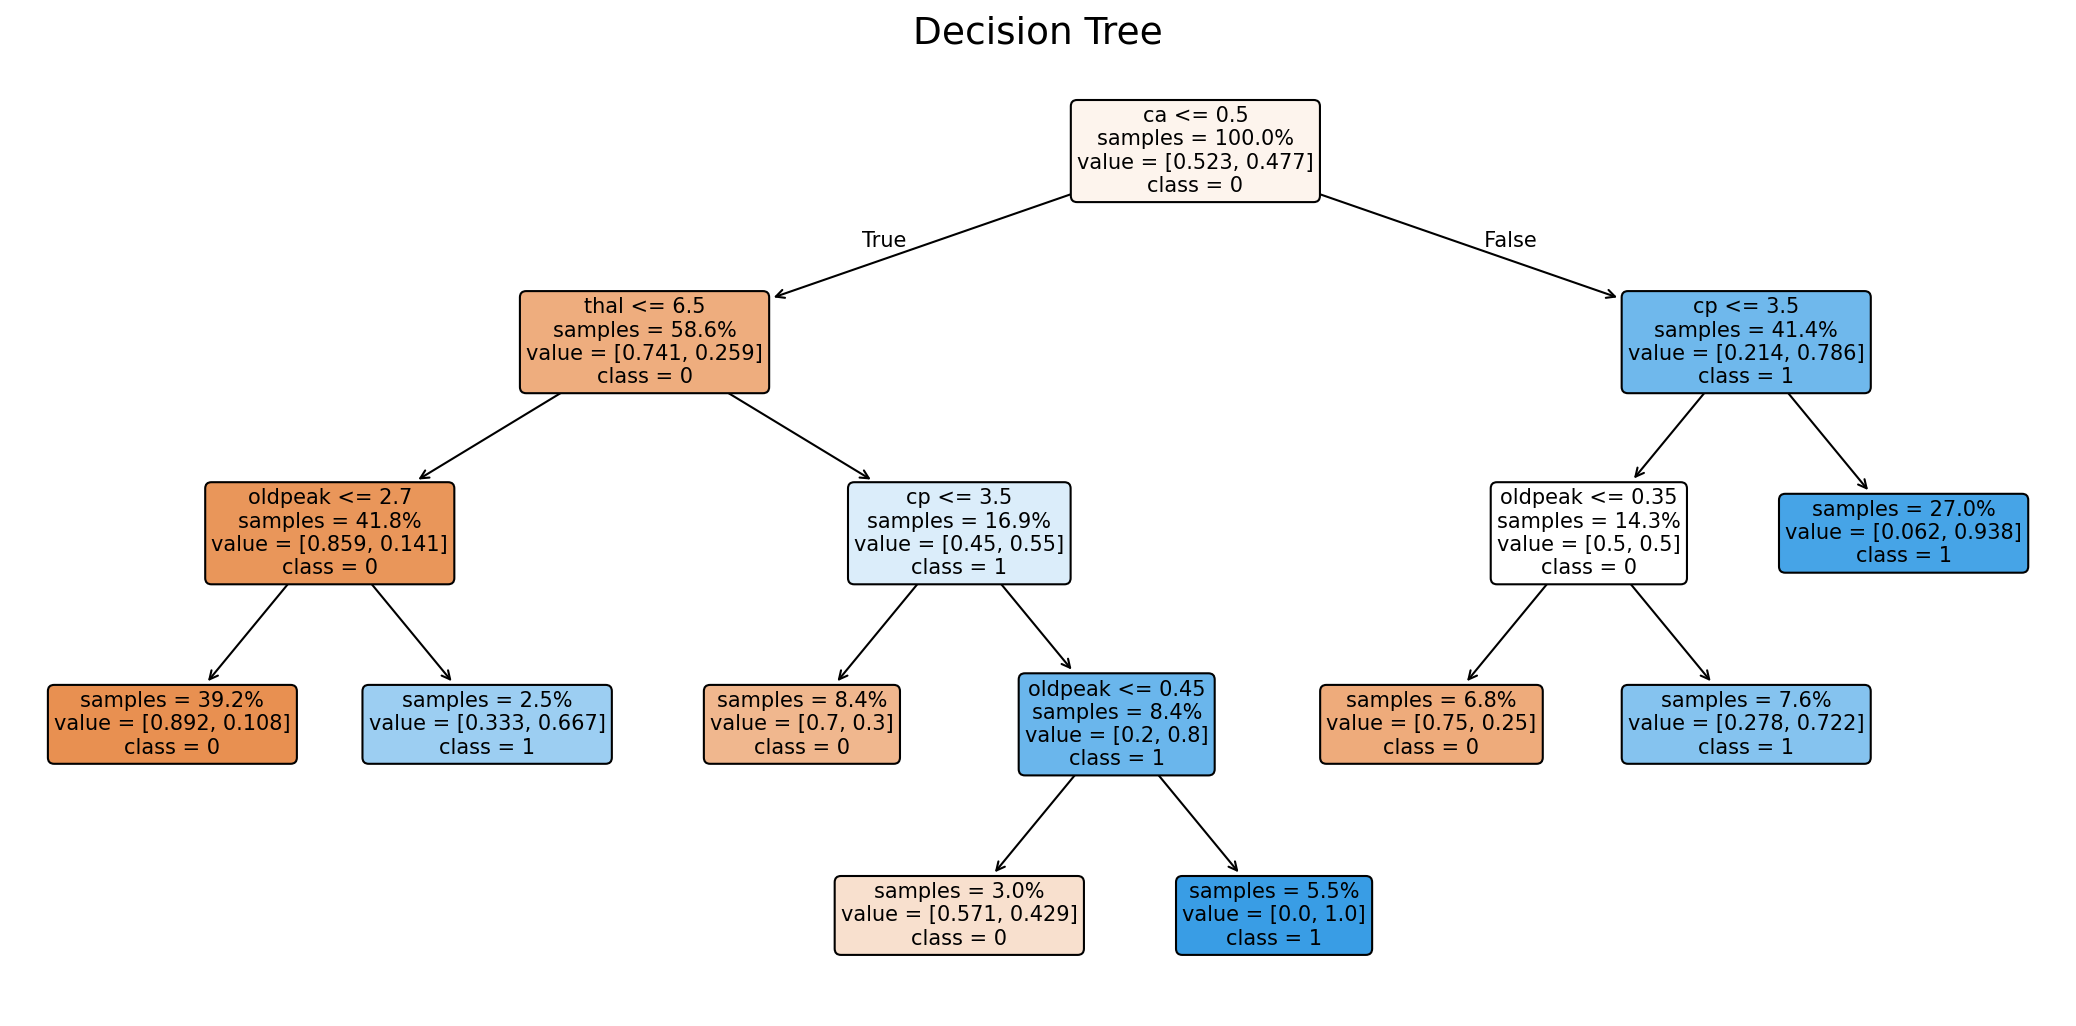

In [15]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
class_names = [str(c) for c in model_dt.classes_]
plot_tree(model_dt,
     filled=True,
     rounded=True,
     feature_names=X.columns,
     class_names=class_names,
     proportion=True,
     impurity=False,
     fontsize=10,
     ax=ax)
plt.title("Decision Tree", fontsize=18)
plt.tight_layout()
plt.show()

,Decision Tree
Accuracy,0.7833
Precision,0.7037
Sensitivity,0.7917
Specificity,0.7778
F1-score,0.8571
AUC (ROC),0.8929


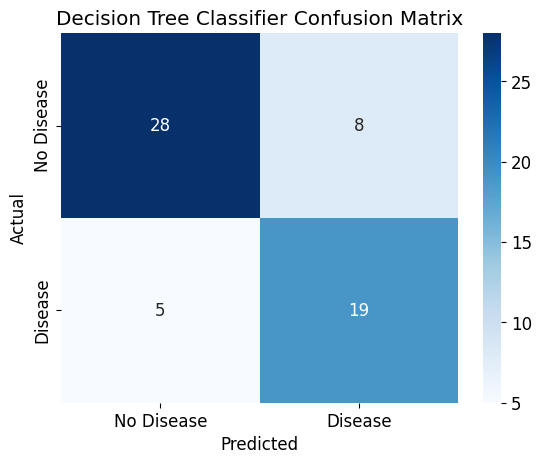

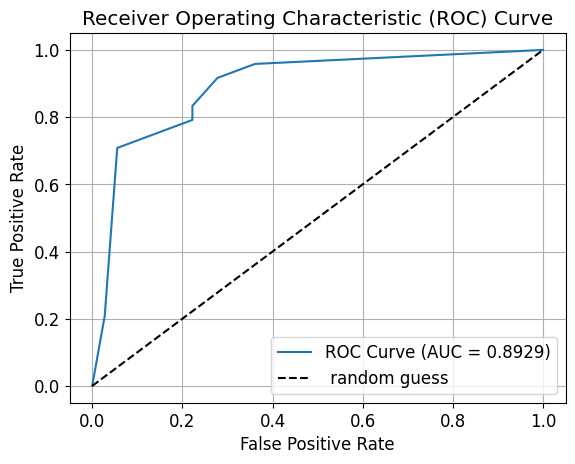

In [16]:
# Evaluation 
y_pred_dt = model_dt.predict(X_test)
# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
sensitivity_dt = recall_score(y_test, y_pred_dt)  # sensitivity
cm_dt = confusion_matrix(y_test, y_pred_dt)
specificity_dt = cm_dt[0,0] / (cm_dt[0,0] + cm_dt[0,1]) if (cm_dt[0,0] + cm_dt[0,1]) > 0 else np.nan
f1_dt = f1_score(y_test, y_pred_lr)
auc_score_dt = roc_auc_score(y_test, model_dt.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_dt = {
     'Decision Tree': [
          accuracy_dt,
          precision_dt,
          sensitivity_dt,
          specificity_dt,
          f1_dt, 
          auc_score_dt
     ]
}

metrics_dt_df = pd.DataFrame(metrics_dt, index=metrics_index)
display(metrics_dt_df.round(4))

# plot confusion matrix
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'ROC Curve (AUC = {auc_score_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()


# IV. Random Forests 

In [17]:
# create the model and find the best hyperparameters
model_rf = RandomForestClassifier(random_state=42)

param_grid = {
     'n_estimators' : [150, 200],
     'max_samples' : [0.8, 0.9],
     'max_depth' : [2, 3, 5],
     'min_samples_leaf' : [3, 4],
     'ccp_alpha' : [0, 0.01]
}
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)


Best Hyperparameters: {'ccp_alpha': 0, 'max_depth': 2, 'max_samples': 0.8, 'min_samples_leaf': 4, 'n_estimators': 150}
Best Estimator: RandomForestClassifier(ccp_alpha=0, max_depth=2, max_samples=0.8,
                       min_samples_leaf=4, n_estimators=150, random_state=42)


In [18]:
# Train the tree with best hyperparameters
model_rf = best_estimator
model_rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,Random Forest
Accuracy,0.9167
Precision,0.9130
Sensitivity,0.8750
Specificity,0.9444
F1-score,0.8936
AUC (ROC),0.9606


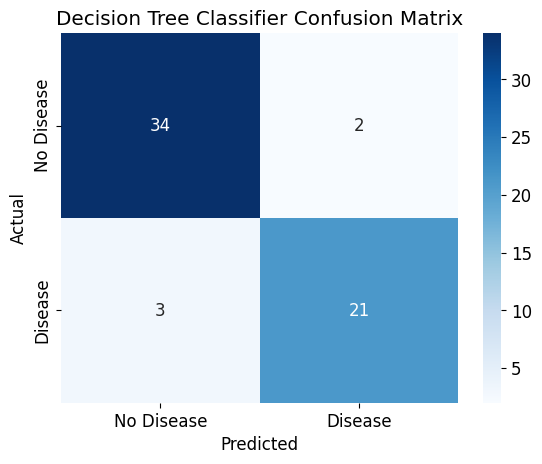

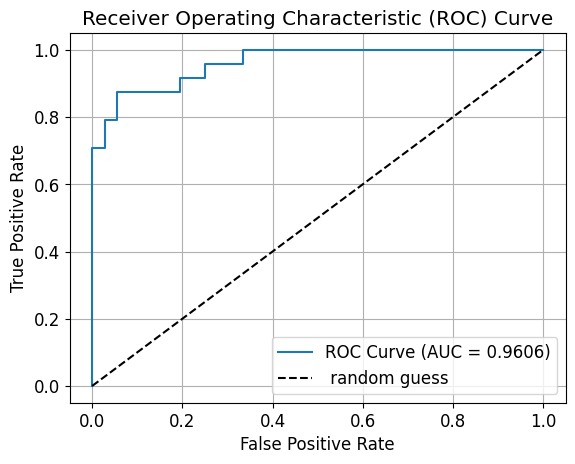

In [19]:
# Evaluation
y_pred_rf = model_rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
sensitivity_rf = recall_score(y_test, y_pred_rf)  # sensitivity
cm_rf = confusion_matrix(y_test, y_pred_rf)
specificity_rf = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[0,1]) if (cm_rf[0,0] + cm_rf[0,1]) > 0 else np.nan
f1_rf = f1_score(y_test, y_pred_rf)
auc_score_rf = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_rf = {
     'Random Forest': [
          accuracy_rf,
          precision_rf,
          sensitivity_rf,
          specificity_rf,
          f1_rf,
          auc_score_rf
     ]
}

metrics_rf_df = pd.DataFrame(metrics_rf, index=metrics_index)
display(metrics_rf_df.round(4))

# plot confusion matrix
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'ROC Curve (AUC = {auc_score_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

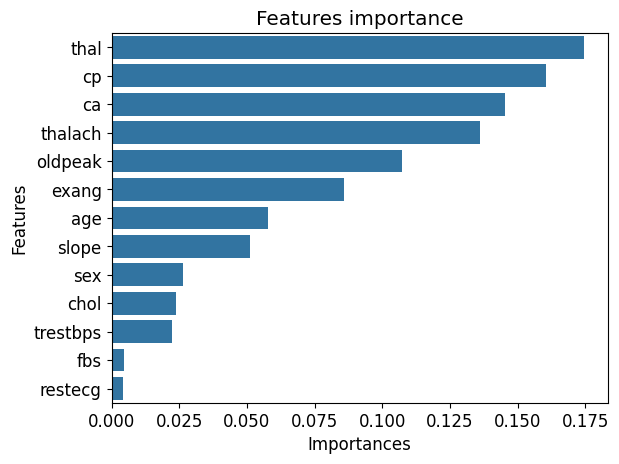

In [20]:
# features importance
feature_importances_rf = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.subplot()
sns.barplot(x=feature_importances_rf.values, y=feature_importances_rf.index)
plt.title("Features importance")
plt.xlabel("Importances")
plt.ylabel("Features")
plt.show()

# V. XgBoost

In [21]:
# Create the model and find the optimal hyperparameters
model_xg = xgb.XGBClassifier(random_state=42)
param_grid = {
     'n_estimators' : [100, 150, 200],
     'learning_rate' : [0.1, 0.2],
     'max_depth' : [2, 3],
     'subsample' : [0.8, 0.9],
     'colsample_bytree' : [0.8, 0.9]
}
grid_search = GridSearchCV(estimator=model_xg, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)

Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}
Best Estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)


In [22]:
# train the model
model_xg = best_estimator
model_xg.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


,XGBoost
Accuracy,0.8667
Precision,0.7857
Sensitivity,0.9167
Specificity,0.8333
F1-score,0.8571
AUC (ROC),0.9213


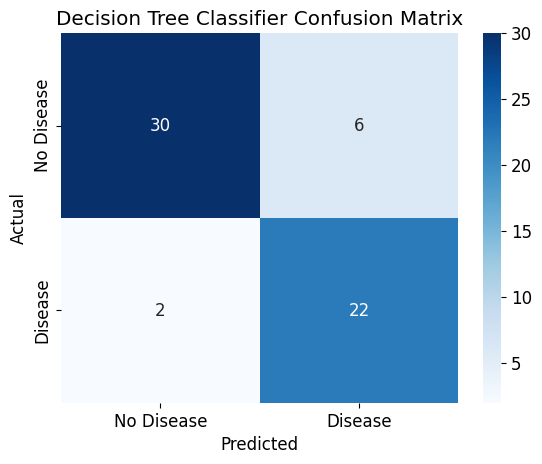

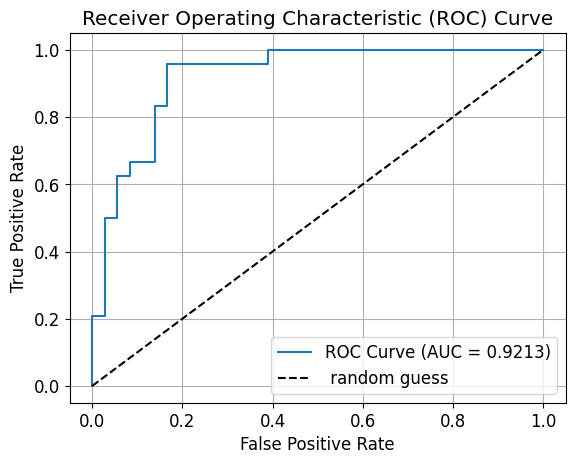

In [23]:
# Evaluation 
y_pred_xg = model_xg.predict(X_test)
# Calculate metrics
accuracy_xg = accuracy_score(y_test, y_pred_xg)
precision_xg = precision_score(y_test, y_pred_xg)
sensitivity_xg = recall_score(y_test, y_pred_xg)  # sensitivity
cm_xg = confusion_matrix(y_test, y_pred_xg)
specificity_xg = cm_xg[0,0] / (cm_xg[0,0] + cm_xg[0,1]) if (cm_xg[0,0] + cm_xg[0,1]) > 0 else np.nan
f1_xg = f1_score(y_test, y_pred_lr)
auc_score_xg = roc_auc_score(y_test, model_xg.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_xg = {
     'XGBoost': [
          accuracy_xg,
          precision_xg,
          sensitivity_xg,
          specificity_xg,
          f1_xg,
          auc_score_xg
     ]
}

metrics_xg_df = pd.DataFrame(metrics_xg, index=metrics_index)
display(metrics_xg_df.round(4))

# plot confusion matrix
sns.heatmap(cm_xg, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_xg = model_xg.predict_proba(X_test)[:, 1]
fpr_xg, tpr_xg, thresholds = roc_curve(y_test, y_prob_xg)
plt.plot(fpr_xg, tpr_xg, label=f'ROC Curve (AUC = {auc_score_xg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

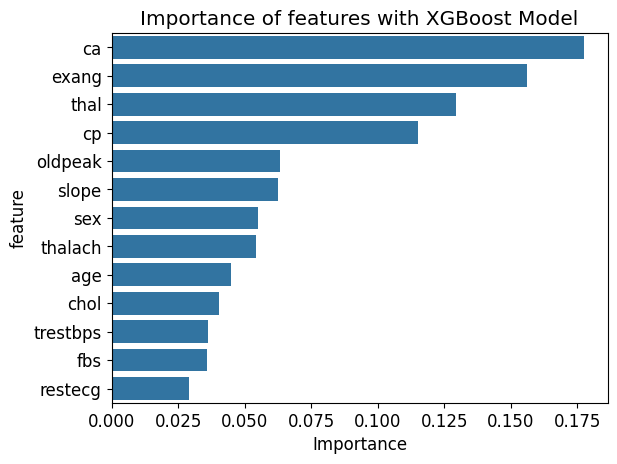

In [24]:
# features importances
feature_importances_xg = pd.Series(model_xg.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances_xg.values, y=feature_importances_xg.index)
plt.title("Importance of features with XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("feature")
plt.show()

The results for feature importance are broadly similar. We can observe that the XGBoost model is slightly more balanced, whereas the Random Forest model has effectively eliminated the last two variables. We should also question the stability of these results. One potential avenue for improvement could be the integration of surrogate splits.

# VI. Comparison

,Logistic Regression,Decision Tree,Random Forest,XGboost
Accuracy,0.883333,0.783333,0.916667,0.866667
Precision,0.840000,0.703704,0.913043,0.785714
Sensitivity,0.875000,0.791667,0.875000,0.916667
Specificity,0.888889,0.777778,0.944444,0.833333
F1-score,0.857143,0.857143,0.893617,0.857143
AUC (ROC),0.946759,0.892940,0.960648,0.921296


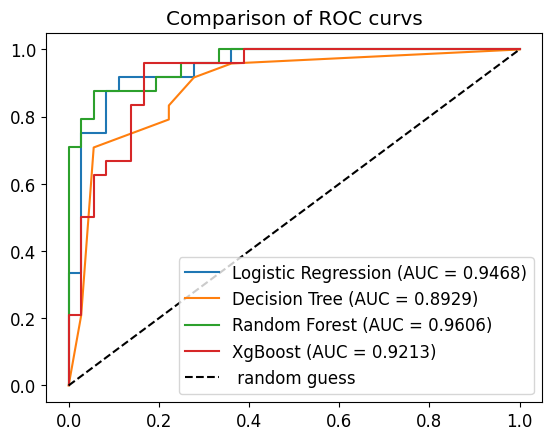

In [25]:
# Compare metrics
comparison_df = pd.DataFrame({
     'Logistic Regression' : metrics_lr['Logistic Regression'],
     'Decision Tree' : metrics_dt['Decision Tree'], 
     'Random Forest' : metrics_rf['Random Forest'],
     'XGboost' : metrics_xg['XGBoost']
}, index=metrics_index)
display(comparison_df)

# plot ROC curv
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_score_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_score_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_score_rf:.4f})')
plt.plot(fpr_xg, tpr_xg, label=f'XgBoost (AUC = {auc_score_xg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.title("Comparison of ROC curvs")
plt.legend()
plt.show()


Considering all these metrics, the most performant model is the Random Forest. However, we still note that the XGBoost model yields a higher sensitivity (or Recall).

In our case, the cost of a False Negative is very high. Indeed, failing to detect the presence of a serious disease in a patient significantly decreases their chances of survival. For instance, consider this statistic: localized breast cancer offers an average net 5-year survival rate of over 90%, whereas this rate drops substantially for non-localized forms. (Source: https://radiotherapie-hartmann.fr/actualites/divers/chances-survie-associees-aux-cancers/). Conversely, we imagine that a False Positive would be quickly ruled out after subsequent tests.

Therefore, one avenue for future consideration would be to integrate this cost knowledge by updating the priors in our model. We should also highlight the good performance of Logistic Regression (AUC=0.9213) considering the model's simplicity, especially when compared to the lower score of the Decision Tree model.

